# **ANN 7 – Write a Python Program to implement a 2-layer Neural Network that learns the XOR function.**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class NeuralNetwork:
    """
    A 2-layer Neural Network to solve the XOR problem.
    Architecture: 2 input neurons, 1 hidden layer with 4 neurons, 1 output neuron.
    """
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.5):
        # Initialize weights with small random values to break symmetry
        self.W1 = np.random.randn(input_size, hidden_size) * 0.1
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.1
        self.b2 = np.zeros((1, output_size))
        self.learning_rate = learning_rate

    def _sigmoid(self, x):
        """Sigmoid activation function."""
        return 1 / (1 + np.exp(-x))

    def _sigmoid_derivative(self, x):
        """Derivative of the sigmoid function."""
        return x * (1 - x)

    def forward(self, X):
        """
        Performs the forward pass through the network.
        Returns the final output.
        """
        # Layer 1 (Hidden)
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self._sigmoid(self.z1)
        
        # Layer 2 (Output)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.output = self._sigmoid(self.z2)
        return self.output

    def backward(self, X, y):
        """
        Performs the backward pass and updates the weights (backpropagation).
        """
        # --- Calculate gradients using the chain rule ---
        
        # Error at the output layer
        output_error = y - self.output
        output_delta = output_error * self._sigmoid_derivative(self.output)

        # Error at the hidden layer (propagated back from the output)
        hidden_error = output_delta.dot(self.W2.T)
        hidden_delta = hidden_error * self._sigmoid_derivative(self.a1)

        # --- Update weights and biases ---
        self.W2 += self.a1.T.dot(output_delta) * self.learning_rate
        self.b2 += np.sum(output_delta, axis=0, keepdims=True) * self.learning_rate
        self.W1 += X.T.dot(hidden_delta) * self.learning_rate
        self.b1 += np.sum(hidden_delta, axis=0, keepdims=True) * self.learning_rate

    def train(self, X, y, epochs=20000):
        """
        Trains the network for a specified number of epochs.
        """
        loss_history = []
        for epoch in range(epochs):
            output = self.forward(X)
            self.backward(X, y)
            
            # Record the loss every 100 epochs for plotting
            if epoch % 100 == 0:
                loss = np.mean(np.square(y - output))
                loss_history.append(loss)
                print(f"Epoch {epoch}: Loss = {loss:.6f}")
                
        return loss_history

Epoch 0: Loss = 0.250358
Epoch 100: Loss = 0.250000
Epoch 200: Loss = 0.250000
Epoch 300: Loss = 0.250000
Epoch 400: Loss = 0.250000
Epoch 500: Loss = 0.250000
Epoch 600: Loss = 0.250000
Epoch 700: Loss = 0.250000
Epoch 800: Loss = 0.250000
Epoch 900: Loss = 0.250000
Epoch 1000: Loss = 0.250000
Epoch 1100: Loss = 0.250000
Epoch 1200: Loss = 0.250000
Epoch 1300: Loss = 0.250000
Epoch 1400: Loss = 0.250000
Epoch 1500: Loss = 0.250000
Epoch 1600: Loss = 0.250000
Epoch 1700: Loss = 0.250000
Epoch 1800: Loss = 0.250000
Epoch 1900: Loss = 0.250000
Epoch 2000: Loss = 0.250000
Epoch 2100: Loss = 0.250000
Epoch 2200: Loss = 0.250000
Epoch 2300: Loss = 0.250000
Epoch 2400: Loss = 0.250000
Epoch 2500: Loss = 0.250000
Epoch 2600: Loss = 0.250000
Epoch 2700: Loss = 0.250000
Epoch 2800: Loss = 0.250000
Epoch 2900: Loss = 0.250000
Epoch 3000: Loss = 0.250000
Epoch 3100: Loss = 0.250000
Epoch 3200: Loss = 0.250000
Epoch 3300: Loss = 0.250000
Epoch 3400: Loss = 0.250000
Epoch 3500: Loss = 0.250000
Epoc

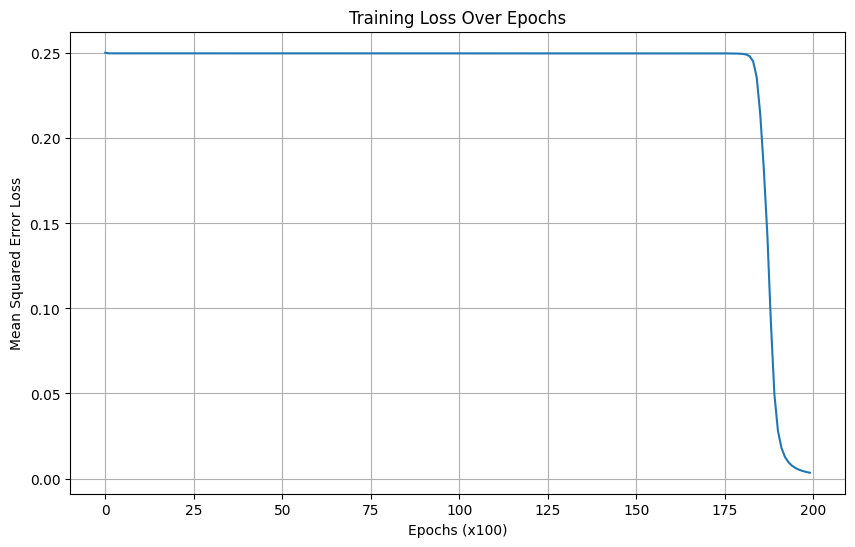

In [3]:
# --- Data, Training, and Results ---

if __name__ == "__main__":
    # XOR function inputs and expected outputs
    X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    y = np.array([[0], [1], [1], [0]])

    # Initialize and train the network
    nn = NeuralNetwork(input_size=2, hidden_size=4, output_size=1, learning_rate=0.5)
    loss_history = nn.train(X, y)

    # --- Results and Visualization ---
    print("\nTraining finished.")
    print("Final predictions:")
    predictions = nn.forward(X)
    for i in range(len(X)):
        print(f"Input: {X[i]} -> Predicted: {predictions[i][0]:.4f} (Correct Output: {y[i][0]})")

    # Plot the loss curve
    plt.figure(figsize=(10, 6))
    plt.plot(loss_history)
    plt.title("Training Loss Over Epochs")
    plt.xlabel("Epochs (x100)")
    plt.ylabel("Mean Squared Error Loss")
    plt.grid(True)
    plt.show()